# 01 — Exploratory Data Analysis: Business Entity Resolution

**Goal of this notebook:** understand the data well enough to make every design decision in the
pipeline *from evidence*, not from assumptions. Each section ends with a short **Takeaway**; the
final section collects them into **EDA conclusions → design decisions**.

Sections
1. Loading the data correctly (the `sep` trap)
2. Scale and country mix (train vs test)
3. Label structure — how many matches does an S1 entity have?
4. The partition property — can one S2/S3 record belong to two S1 entities?
5. Field quality — empties, scripts, domain-style names, junk prefixes
6. Noise taxonomy — real matched clusters
7. True pairs vs random pairs — which similarity signals separate them?
8. Blocking-key coverage — what recall ceiling do cheap keys give?
9. Legal suffixes and abbreviations — can we mine them instead of hardcoding?
10. France (test-only country)
11. EDA conclusions → design decisions

Memory note: the machine has 8 GB RAM, so full files are only scanned column-wise (pyarrow) and the
heavier analyses use a random sample of S1 entities plus their true matches.

In [1]:
import csv, re, time, unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.csv as pacsv
import matplotlib.pyplot as plt
import jellyfish
from rapidfuzz import fuzz

DATA = Path('../student_resource/dataset')
RNG = np.random.default_rng(42)
BLUE, ORANGE = '#2a78d6', '#eb6834'          # validated categorical slots 1 and 2
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True})
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.width', 200)

FILES = {f'{split}_s{n}': DATA / split / f'{split}_source{n}.tsv'
         for split in ('train', 'test') for n in (1, 2, 3)}


def read_tsv(path, **kw):
    """Read a challenge TSV safely: explicit tab, no quote handling, empty strings stay empty (not NaN)."""
    return pd.read_csv(path, sep='\t', quoting=csv.QUOTE_NONE, dtype=str, keep_default_na=False, **kw)


def read_arrow(path, columns=None):
    """Fast column-subset read of a full TSV with pyarrow (quote_char=False: data contains stray quotes)."""
    return pacsv.read_csv(path, parse_options=pacsv.ParseOptions(delimiter='\t', quote_char=False),
                          convert_options=pacsv.ConvertOptions(include_columns=columns,
                                                               strings_can_be_null=False,
                                                               column_types={'entity_id': pa.string(), 'country': pa.string(),
                                                                             'business_name': pa.string(), 'business_address': pa.string()}))

## 1. Loading the data correctly

The problem statement warns that reading a `.tsv` without `sep="\t"` silently yields a single column.
Some records also contain stray `"` characters, so quote handling must be switched off too.

In [2]:
wrong = pd.read_csv(FILES['train_s1'], nrows=3)
right = read_tsv(FILES['train_s1'], nrows=3)
print('without sep  ->', wrong.shape, list(wrong.columns)[:1])
print('with sep=\\t ->', right.shape, list(right.columns))
with open(FILES['train_s2'], encoding='utf-8') as f:
    n_quotes = f.read(50_000_000).count('"')
print('double-quote characters in first 50 MB of train_source2:', n_quotes)
right

without sep  -> (3, 1) ['entity_id\tbusiness_name\tbusiness_address\tcountry']
with sep=\t -> (3, 4) ['entity_id', 'business_name', 'business_address', 'country']
double-quote characters in first 50 MB of train_source2: 8


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US


## 2. Scale and country mix

In [3]:
t0 = time.time()
country_tables = {}
rows = []
for key, path in FILES.items():
    tbl = read_arrow(path, ['country'])
    vc = pd.Series(tbl.column('country').to_pylist()).value_counts()
    country_tables[key] = vc
    rows.append({'file': path.name, 'rows': tbl.num_rows, 'size_MB': round(path.stat().st_size / 1e6)})
gt_path = DATA / 'train' / 'train_ground_truth.tsv'
rows.append({'file': gt_path.name, 'rows': sum(1 for _ in open(gt_path, 'rb')) - 1,
             'size_MB': round(gt_path.stat().st_size / 1e6)})
scale = pd.DataFrame(rows)
print(f'scanned in {time.time() - t0:.1f}s')
scale

scanned in 2.6s


,file,rows,size_MB
0,train_source1.tsv,2206821,210
1,train_source2.tsv,5034616,489
2,train_source3.tsv,5285603,504
3,test_source1.tsv,1732544,175
4,test_source2.tsv,4887273,509
5,test_source3.tsv,5082316,506
6,train_ground_truth.tsv,2206821,127


,train_s1,train_s2,train_s3,test_s1,test_s2,test_s3
France,0.00,0.00,0.00,14.98,14.39,14.40
India,40.02,40.08,40.02,46.75,47.32,47.32
US,59.98,59.92,59.98,38.27,38.29,38.28


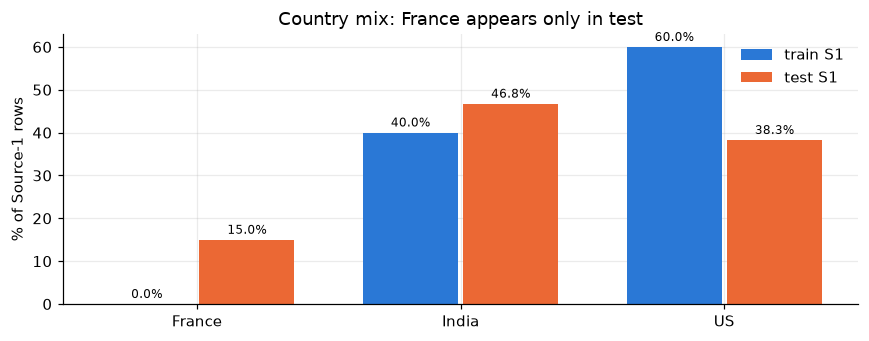

In [4]:
mix = pd.DataFrame({k: v / v.sum() * 100 for k, v in country_tables.items()}).fillna(0).round(2)
display(mix)

fig, ax = plt.subplots(figsize=(8, 3.2))
countries = list(mix.index)
x = np.arange(len(countries)); w = 0.38
for i, (split, color) in enumerate([('train_s1', BLUE), ('test_s1', ORANGE)]):
    bars = ax.bar(x + (i - 0.5) * w, mix[split].values, w - 0.02, color=color, label=split.replace('_s1', ' S1'))
    ax.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)
ax.set_xticks(x, countries); ax.set_ylabel('% of Source-1 rows')
ax.set_title('Country mix: France appears only in test')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

**Takeaway.** ~12.5M training rows and ~11.7M test rows — brute force (S1 × S2∪S3) is on the order
of 10¹³ pairs, so *blocking is mandatory* and the pipeline must be streamed / chunked (8 GB RAM).
The test set has a third country, **France (~15%)**, that never appears in training, so no feature or
rule may be country-specific; `country` can only be used as an equality key.

## 3. Label structure

n,0,1,2,3,4,5,6,7,8,9,10,11
entities,123247.00,119157.0,375212.0,530841.00,484115.00,321957.00,164868.00,63968.0,18680.00,4205.00,534.00,37.0
pct,5.58,5.4,17.0,24.05,21.94,14.59,7.47,2.9,0.85,0.19,0.02,0.0


S1 entities: 2,206,821   total links: 7,638,365   mean matches: 3.46   max: 11
singletons: 5.58%   entities with >=1 S2 match: 86.96%   >=1 S3 match: 87.93%
mean S2 matches: 1.67   mean S3 matches: 1.79


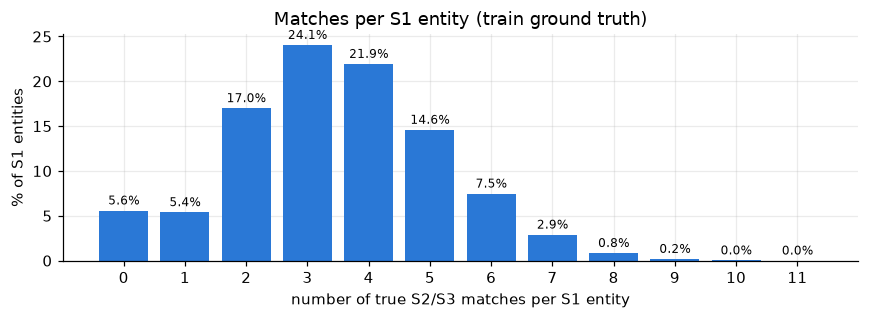

In [5]:
gt = read_tsv(gt_path)
gt['ids'] = gt['matched_entity_ids'].map(lambda s: s.split(',') if s else [])
gt['n'] = gt['ids'].map(len)
gt['n_s2'] = gt['ids'].map(lambda l: sum(i.startswith('S2-') for i in l))
gt['n_s3'] = gt['n'] - gt['n_s2']

dist = gt['n'].value_counts().sort_index()
summary = pd.DataFrame({'entities': dist, 'pct': (dist / len(gt) * 100).round(2)})
display(summary.T)
print(f'S1 entities: {len(gt):,}   total links: {gt.n.sum():,}   mean matches: {gt.n.mean():.2f}   max: {gt.n.max()}')
print(f'singletons: {(gt.n == 0).mean():.2%}   entities with >=1 S2 match: {(gt.n_s2 > 0).mean():.2%}   >=1 S3 match: {(gt.n_s3 > 0).mean():.2%}')
print('mean S2 matches:', round(gt.n_s2.mean(), 2), '  mean S3 matches:', round(gt.n_s3.mean(), 2))

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.bar(dist.index, dist.values / len(gt) * 100, 0.8, color=BLUE)
ax.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)
ax.set_xlabel('number of true S2/S3 matches per S1 entity'); ax.set_ylabel('% of S1 entities')
ax.set_title('Matches per S1 entity (train ground truth)'); ax.set_xticks(dist.index)
plt.tight_layout(); plt.show()

**Takeaway.** 2,206,821 S1 entities carry 7,638,365 links (mean **3.46**, max 11); **77.6%** have 2–5
matches and only **5.58%** are singletons. S2 and S3 contribute about equally (~1.7 matches each).
Predicting "no match" is almost always wrong, yet
singletons still matter: each correctly-empty prediction scores a full 1.0 and *any* prediction on
them scores 0.0. The decision layer must choose **how many** matches per entity (mostly 2–5), not
just threshold pairs, and it needs an explicit way to predict "none".

## 4. The partition property

If no S2/S3 record is ever claimed by two different S1 entities, the truth is a *partition* and we
can enforce "one owner per satellite record" at decision time.

In [6]:
links = gt[['source1_entity_id', 'ids']].explode('ids').dropna()
links = links[links['ids'] != '']
n_links, n_distinct = len(links), links['ids'].nunique()
print(f'links: {n_links:,}   distinct S2/S3 ids: {n_distinct:,}   ids claimed by >1 entity: {n_links - n_distinct:,}')

linked = set(links['ids'])
for key in ('train_s2', 'train_s3'):
    total = int(country_tables[key].sum())
    n_l = sum(1 for i in linked if i.startswith('S' + key[-1] + '-'))
    print(f'{key}: {total:,} rows, {n_l:,} linked -> {1 - n_l / total:.1%} are distractors (match nothing)')

links: 7,638,365   distinct S2/S3 ids: 7,638,365   ids claimed by >1 entity: 0


train_s2: 5,034,616 rows, 3,693,619 linked -> 26.6% are distractors (match nothing)


train_s3: 5,285,603 rows, 3,944,746 linked -> 25.4% are distractors (match nothing)


**Takeaway.** 7,638,365 links over 7,638,365 distinct ids — zero collisions: every satellite record has **at most one owner**. This is a hard
constraint we can exploit (greedy "claimed" assignment in the decision layer) — any second claim on a
record is guaranteed to be a false positive. **26.6% of S2 and 25.4% of S3** records are pure distractors,
so a satellite being *similar* to an S1 entity is not enough to call it a match.

## 5. Field quality

Measured on the first 300k rows of each source file (IDs are random, so file order is effectively random).

In [7]:
DOMAIN = re.compile(r'^[\w-]+\.(com|net|org|in|co|fr|biz|info|us|io)\b', re.I)
JUNK = re.compile(r'^[^\w\s]')  # python `re` (Unicode \w); pandas 3 .str regex is RE2 where \w is ASCII-only

def script_of(s):
    """Unicode script of the first non-ASCII letter (e.g. DEVANAGARI, LATIN, KANNADA) or '' if pure ASCII."""
    for ch in s:
        if ord(ch) > 127 and ch.isalpha():
            return unicodedata.name(ch, 'UNKNOWN').split()[0]
    return ''

samples, quality = {}, []
for key, path in FILES.items():
    df = read_tsv(path, nrows=300_000)
    samples[key] = df
    name, addr = df['business_name'], df['business_address']
    quality.append({
        'file': key,
        'empty_name_%': (name.str.strip() == '').mean() * 100,
        'empty_addr_%': (addr.str.strip() == '').mean() * 100,
        'non_ascii_name_%': (name.map(script_of) != '').mean() * 100,
        'domain_name_%': name.str.match(DOMAIN).mean() * 100,
        'junk_prefix_%': name.map(lambda v: bool(JUNK.match(v))).mean() * 100,
        'brackets_%': name.str.contains(r'[\[\]()]').mean() * 100,
        'all_caps_name_%': (name.str.isupper()).mean() * 100,
        'mean_name_len': name.str.len().mean(),
        'mean_addr_len': addr.str.len().mean(),
    })
pd.DataFrame(quality).set_index('file').round(2)

,empty_name_%,empty_addr_%,non_ascii_name_%,domain_name_%,junk_prefix_%,brackets_%,all_caps_name_%,mean_name_len,mean_addr_len
file,,,,,,,,,
train_s1,0.0,0.00,0.00,0.00,0.15,2.09,0.00,24.04,52.07
train_s2,0.0,3.33,15.05,3.43,2.21,7.75,18.87,25.08,46.31
train_s3,0.0,3.29,11.56,3.35,2.16,7.99,3.01,25.21,46.76
test_s1,0.0,0.00,2.34,0.00,0.13,3.63,0.00,23.85,57.15
test_s2,0.0,2.65,19.04,2.71,1.77,8.27,17.59,25.70,50.38
test_s3,0.0,2.67,14.47,2.78,1.75,8.70,3.18,25.64,48.72


In [8]:
scripts = pd.DataFrame({k: df['business_name'].map(script_of).value_counts() for k, df in samples.items()}).fillna(0).astype(int)
scripts = scripts.drop(index='', errors='ignore')
scripts.loc[scripts.sum(axis=1).sort_values(ascending=False).index]

,train_s1,train_s2,train_s3,test_s1,test_s2,test_s3
business_name,,,,,,
LATIN,0,17297,18783,7029,23549,24504
DEVANAGARI,0,15824,9051,0,19020,10706
TELUGU,0,2332,1347,0,2824,1559
KANNADA,0,2174,1240,0,2768,1515
TAMIL,0,1931,1144,0,2364,1321
BENGALI,0,1835,1050,0,2113,1238
GUJARATI,0,1827,1000,0,2082,1218
MALAYALAM,0,1108,566,0,1366,753
ORIYA,0,428,238,0,547,299


In [9]:
print('junk-prefixed names:'); print(samples['train_s2'].loc[samples['train_s2'].business_name.map(lambda v: bool(JUNK.match(v))), 'business_name'].head(8).tolist())
print('domain-style names:'); print(samples['train_s3'].loc[samples['train_s3'].business_name.str.match(DOMAIN), 'business_name'].head(8).tolist())

# Address component order: does the address start with the street (a number) or with the city/state?
def starts_with_number(a):
    first = a.split(',')[0]
    return bool(re.search(r'\d', first))
order = pd.DataFrame({k: [df['business_address'].map(starts_with_number).mean() * 100] for k, df in samples.items()},
                     index=['% addresses whose first comma-part contains a number']).round(1)
order

junk-prefixed names:
['-- Holloway Peak Inc Seafood', '[INCORPORATED] PEAK TRADIN6 NETWORKS SOUTHSIDE', '*** Country  Real', '*** Sai Tech Private Limited', '@DENTCOFFEE', '... White Safe Futurecorp LP', '... Foods Shaper Private Ltd', '... Ace Smart [Solutions]']
domain-style names:
['wilfordhancock.com', 'Hmgreen.Com', 'erwinsignaturekrakacquisition.com', 'Bonnettresilience.Com', '7m.com', 'patnasolutions.com', 'Sweetbarbershop.Com', 'Oncologyspecialists.Com']


,train_s1,train_s2,train_s3,test_s1,test_s2,test_s3
% addresses whose first comma-part contains a number,81.5,78.0,77.3,80.5,80.2,78.9


**Takeaway.**
* Source 1 is clean by construction (0% empty addresses, 0% non-ASCII in train); **all noise lives in S2/S3**.
* **~3.3% (train) / ~2.7% (test)** of satellite records have **no address** → they need a name-only path in the model.
* **11–19%** of satellite names are non-ASCII: mostly **Devanagari**, plus **eight other Indic scripts**
  (Telugu, Kannada, Tamil, Bengali, Gujarati, Malayalam, Oriya, Gurmukhi) and accented Latin
  (spurious accents / French). Test S2 has *more* non-ASCII names (19%) than train S2 (15%). Because all Indic Unicode blocks share the same
  internal layout, **one romanisation table keyed by offset** covers every Indic script.
* Domain-style names (~3%, `wilfordhancock.com`), junk prefixes (~2%, `--`, `***`, `...`), brackets (~8%)
  and ALL-CAPS (19% of S2) are systematic noise → a canonical "squash" form (alphanumerics only) neutralises all three.
* Roughly **1 in 5** addresses starts with city/state instead of the street — components are **reordered**, so address comparison
  must be **order-invariant** (token sets, not strings).

## 6. Noise taxonomy — real matched clusters

We draw a random sample of 20k S1 entities (with ≥1 match), then pull their true matches out of the
full S2/S3 files.

In [10]:
t0 = time.time()
sample_s1_ids = set(gt.loc[gt.n > 0, 'source1_entity_id'].sample(20_000, random_state=0))
s1_full = read_tsv(FILES['train_s1'])
s1_s = s1_full[s1_full.entity_id.isin(sample_s1_ids)].set_index('entity_id')

sample_links = links[links.source1_entity_id.isin(sample_s1_ids)]
wanted = pa.array(sorted(set(sample_links['ids'])))
parts = []
for key in ('train_s2', 'train_s3'):
    tbl = read_arrow(FILES[key])
    parts.append(tbl.filter(pc.is_in(tbl['entity_id'], value_set=wanted)).to_pandas())
    del tbl
s23_s = pd.concat(parts).set_index('entity_id')
print(f'{len(s1_s):,} S1 entities, {len(s23_s):,} matched satellite records loaded in {time.time() - t0:.0f}s')

def show_cluster(s1_id):
    r = s1_s.loc[s1_id]
    print(f'S1 {s1_id}: {r.business_name!r:50} | {r.business_address}')
    for sid in sample_links.loc[sample_links.source1_entity_id == s1_id, 'ids']:
        m = s23_s.loc[sid]
        print(f'   {sid[:2]}: {m.business_name!r:50} | {m.business_address}')
    print()

for s1_id in list(s1_s[s1_s.country == 'US'].index[:3]) + list(s1_s[s1_s.country == 'India'].index[:3]):
    show_cluster(s1_id)

20,000 S1 entities, 73,531 matched satellite records loaded in 3s
S1 S1-378164861: 'Industrial Wholesale Enterprises'                 | 2507 Branson Landing, Unit Unit 507B, Branson, MO
   S2: 'LP Wholesale-Enterprises Industrial'              | ##2507 Branson Landing, BRANSON, MO
   S2: 'INDUSTRIAL ENTERPRISES WHÓLESALE'                 | BRANSON LANDING, BRANSON, MO
   S3: 'industrialwholesaleenterprises.com'               | 507 Branson Landing, Unit Unit 507B, Branson, Missouri
   S3: 'Industrial Enterprises Services'                  | 507 Branson Landing, # Unit 507B, Branson, Missouri
   S3: 'Industrial Wh0lesale Enterprises'                 | 507 Branson Landing, # Unit 507B, Branson, Missouri

S1 S1-164240371: 'Family Association'                               | OH, Fl 3, Columbus, 5059 Enclave Boulevard
   S2: 'Family Assoniation'                               | OH, COLUMBUS, 5059 ENCLAVE BLVD
   S2: 'Family Association'                               | 5059 ENCLAVE BLVD, OH, C

**Takeaway.** The same noise classes recur in every cluster: legal-suffix drift (`Inc`/`LLC`/`Pvt Ltd`),
names swapped for a domain or **an unrelated brand name**, typos/transpositions, spurious accents,
Devanagari transliteration, street-type abbreviations (`Dr`/`Drive`), state abbreviations
(`NC`/`North Carolina`), `#`/`.` punctuation around house numbers and component reordering.
House numbers survive almost untouched.

## 7. True pairs vs random pairs — which signals separate them?

Canonicalisation used here (the pipeline uses the same idea): Unicode NFKD, strip *Latin* combining
accents only (so Indic vowel signs survive), lowercase, `&`→`and`, punctuation → space.

,true pairs (mean),random same-country pairs (mean)
name_token_jaccard,0.641,0.031
name_squash_ratio,0.796,0.320
addr_token_set_ratio,0.873,0.367
addr_num_jaccard,0.703,0.007
lead_num_equal,0.689,0.003


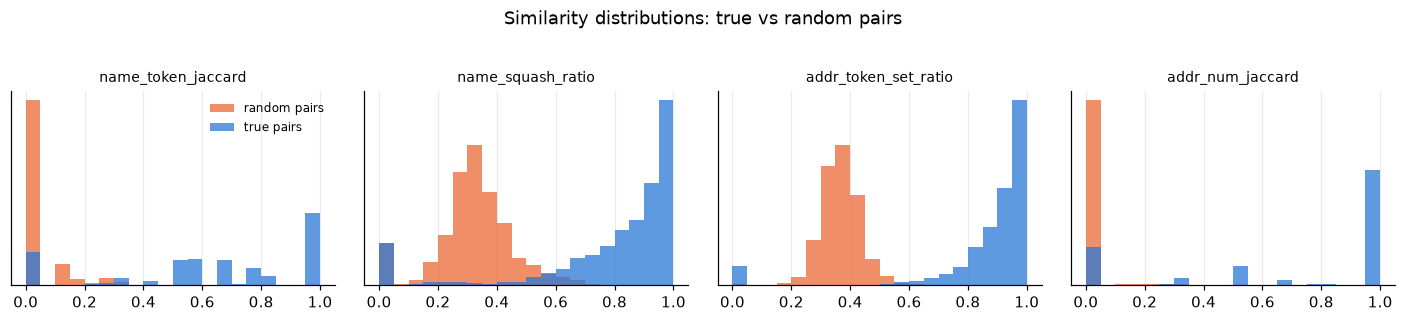

In [11]:
LATIN_MARKS = re.compile('[\u0300-\u036f]')
PUNCT = re.compile(r'[^\w\s\u0900-\u0d7f]')

def canon(s):
    s = LATIN_MARKS.sub('', unicodedata.normalize('NFKD', s)).lower().replace('&', ' and ')
    return ' '.join(PUNCT.sub(' ', s).split())

def squash(s):
    return re.sub(r'[\W_]', '', canon(s))

def nums(a):
    return re.findall(r'\d+', a)

def jacc(a, b):
    return len(a & b) / len(a | b) if a or b else 0.0

pairs = sample_links.rename(columns={'source1_entity_id': 's1', 'ids': 's23'})
pairs = pairs[pairs.s23.isin(s23_s.index)]
# random negatives: each S1 paired with a random satellite record of the same country from the 300k samples
pool = pd.concat([samples['train_s2'], samples['train_s3']]).set_index('entity_id')
pool = pool[~pool.index.isin(linked)]  # true distractors only
neg_rows = []
for country, grp in s1_s.groupby('country'):
    cand = pool[pool.country == country]
    pick = cand.sample(len(grp), replace=True, random_state=1)
    neg_rows.append(pd.DataFrame({'s1': grp.index, 'name2': pick.business_name.values, 'addr2': pick.business_address.values}))
neg = pd.concat(neg_rows)
pos = pd.DataFrame({'s1': pairs.s1.values, 'name2': s23_s.loc[pairs.s23, 'business_name'].values,
                    'addr2': s23_s.loc[pairs.s23, 'business_address'].values})

def pair_features(df):
    n1 = s1_s.loc[df.s1, 'business_name'].values; a1 = s1_s.loc[df.s1, 'business_address'].values
    out = pd.DataFrame(index=df.index)
    out['name_token_jaccard'] = [jacc(set(canon(x).split()), set(canon(y).split())) for x, y in zip(n1, df.name2)]
    out['name_squash_ratio'] = [fuzz.ratio(squash(x), squash(y)) / 100 for x, y in zip(n1, df.name2)]
    out['addr_token_set_ratio'] = [fuzz.token_set_ratio(canon(x), canon(y)) / 100 for x, y in zip(a1, df.addr2)]
    out['addr_num_jaccard'] = [jacc(set(nums(x)), set(nums(y))) for x, y in zip(a1, df.addr2)]
    out['lead_num_equal'] = [float(bool(nums(x)) and bool(nums(y)) and nums(x)[0] == nums(y)[0]) for x, y in zip(a1, df.addr2)]
    return out

fp, fn = pair_features(pos.reset_index(drop=True)), pair_features(neg.reset_index(drop=True))
comp = pd.DataFrame({'true pairs (mean)': fp.mean(), 'random same-country pairs (mean)': fn.mean()}).round(3)
display(comp)

fig, axes = plt.subplots(1, 4, figsize=(13, 2.8))
for ax, col in zip(axes, ['name_token_jaccard', 'name_squash_ratio', 'addr_token_set_ratio', 'addr_num_jaccard']):
    bins = np.linspace(0, 1, 21)
    ax.hist(fn[col], bins, color=ORANGE, alpha=0.75, label='random pairs', density=True)
    ax.hist(fp[col], bins, color=BLUE, alpha=0.75, label='true pairs', density=True)
    ax.set_title(col, fontsize=9); ax.set_yticks([])
axes[0].legend(frameon=False, fontsize=8)
plt.suptitle('Similarity distributions: true vs random pairs', y=1.03); plt.tight_layout(); plt.show()

In [12]:
# How many true pairs have (almost) no name overlap at all — and what rescues them?
no_name = (fp.name_token_jaccard == 0) & (fp.name_squash_ratio < 0.5)
print(f'true pairs with ~zero name similarity: {no_name.mean():.2%}')
print(f'  ...of which lead house-number is equal: {fp.loc[no_name, "lead_num_equal"].mean():.1%}')
print(f'  ...of which address token-set ratio >= 0.8: {(fp.loc[no_name, "addr_token_set_ratio"] >= 0.8).mean():.1%}')
print(f'true pairs with empty satellite address: {(pos.addr2.str.strip() == "").mean():.2%}')
print()
print('examples of zero-name-overlap true pairs:')
ex = pos.loc[no_name.values].head(6)
for _, r in ex.iterrows():
    print(f'  {s1_s.loc[r.s1, "business_name"]!r:40} -> {r.name2!r:30} | {s1_s.loc[r.s1, "business_address"][:45]!r} ~ {r.addr2[:45]!r}')

true pairs with ~zero name similarity: 9.01%
  ...of which lead house-number is equal: 66.1%
  ...of which address token-set ratio >= 0.8: 90.7%
true pairs with empty satellite address: 4.38%

examples of zero-name-overlap true pairs:
  'Universal Foundation Pvt Ltd'           -> 'யுனிவர்சல் ஃபவுண்டேஷன் பிரைவேட் லிமிடெட்' | 'G1, Amirtha Varshini, 131, Old No.52, Kothand' ~ 'CHENNAI, AMIRTHA VARSHINI, 131, OLD NO.52, KO'
  'Universal Foundation Pvt Ltd'           -> 'யுனிவர்சல் ஃபவுண்டேஷன் பிரைவேட் லிமிடெட்' | 'G1, Amirtha Varshini, 131, Old No.52, Kothand' ~ 'GD/1, CHENNAI, Tamil Nadu'
  'Modern Care Private Limited'            -> 'मॉडर्न केयर प्राइवेट लिमिटेड' | 'We-115, Mohan Garden, Rama Park Road, Uttam N' ~ 'PLOT 496 WE-115, NEW DELHI, Delhi'
  'XHY Leasing'                            -> 'Vantageriza'                  | 'Dombivli (East), Thane, Shop No.2, Maharashtr' ~ 'THANE, NO D/2, महाराष्ट्र, DOMBIVLI (EAST)'
  'XHY Leasing'                            -> 'Onyxonyx Labs'       

**Takeaway.** Address numbers are the strongest signal: numeric-token Jaccard is **0.70** on true pairs vs
**0.007** on random pairs, and the lead number agrees on **69%** of true pairs vs **0.3%** of random ones.
The lead number is noisier than expected though — satellites inject extra numbers (`NO ##135 2804`) —
so features and keys should use the *set* of numbers, not only the first one.
Name similarity is strong but not sufficient: **9%** of true pairs have ~zero name similarity
(transliterated names, rebrands like `Belobrixmira`); 91% of those still have address token-set
ratio ≥ 0.8, so they are recoverable **through the address**. **4.4%** of true pairs have an empty
satellite address and are recoverable only through the name. So the pipeline must be **address-first**, with name as the
second signal, and must keep a name-only fallback for empty addresses.

## 8. Blocking-key coverage (recall ceiling of cheap keys)

For each true pair we check whether it would share a candidate key. IDF for address tokens is
estimated from the 600k-row satellite sample.

* **K1** `(country, lead number, first 3 chars of rarest address word)`
* **K2** `(country, two rarest address words)`
* **K3** `(country, first 8 chars of name squash)`
* **K4** `(country, metaphone of first two name words)`

In [13]:
def alpha_tokens(a):
    return [t for t in canon(a).split() if not t.isdigit() and len(t) > 1]

df_count = Counter()
for a in pool.business_address:
    df_count.update(set(alpha_tokens(a)))
N = len(pool)
def idf(t):
    return np.log(N / (1 + df_count.get(t, 0)))

def rare(a, k):
    toks = sorted(set(alpha_tokens(a)), key=lambda t: (-idf(t), t))
    return toks[:k]

def keys(name, addr, country):
    n = nums(addr); r2 = rare(addr, 2); sq = squash(name); words = canon(name).split()[:2]
    return {
        'K1': (country, n[0], r2[0][:3]) if n and r2 else None,
        'K2': (country, tuple(sorted(r2))) if len(r2) == 2 else None,
        'K3': (country, sq[:8]) if len(sq) >= 4 else None,
        'K4': (country, ' '.join(jellyfish.metaphone(w) for w in words)) if words else None,
    }

hit = {k: [] for k in ('K1', 'K2', 'K3', 'K4')}
for s1, n2, a2 in zip(pos.s1, pos.name2, pos.addr2):
    r = s1_s.loc[s1]
    k1, k2 = keys(r.business_name, r.business_address, r.country), keys(n2, a2, r.country)
    for k in hit:
        hit[k].append(k1[k] is not None and k1[k] == k2[k])
hit = pd.DataFrame(hit)
hit['K1|K2'] = hit.K1 | hit.K2
hit['K3|K4'] = hit.K3 | hit.K4
hit['ANY (K1-K4)'] = hit[['K1', 'K2', 'K3', 'K4']].any(axis=1)
recall = hit.mean().mul(100).round(2)
recall.to_frame('% of true pairs sharing the key').T

,K1,K2,K3,K4,K1|K2,K3|K4,ANY (K1-K4)
% of true pairs sharing the key,56.93,68.92,66.88,59.14,76.1,68.61,92.21


### 8b. Refining the keys from what the misses look like

Inspecting misses of the plain keys shows two fixable failure modes:
* **Injected numbers** — satellites prepend extra numbers (`NO ##135 2804`, `PLOT 496 WE-115`), so the
  *lead* number differs even though the real house number is present. → key on **every** number
  (up to 3) × each of the 2 rarest words, not only the lead number.
* **Legal words moved or added** — `Pvt Spd Infosys Limited`, `Incorporated Cross States`,
  `L.L.C.` → `l l c`. → join runs of single letters, and strip legal tokens **anywhere** in the name
  (legal-token set mined as the most frequent trailing tokens of S1 names) before building name keys.

49 legal/generic trailing tokens mined, e.g. ['amicale', 'amis', 'associates', 'care', 'center', 'centre', 'church', 'cie', 'clinic', 'club', 'co', 'comite', 'company', 'corp', 'corporation', 'dame', 'ecole', 'ei', 'eurl', 'foundation', 'france', 'group', 'health', 'holdings', 'inc']


,plain,refined
K1 (address numbers),56.93,74.44
K2 (rare words),68.92,68.92
K3 (name squash),66.88,69.43
K4 (phonetic),59.14,62.05
ANY,92.21,95.35


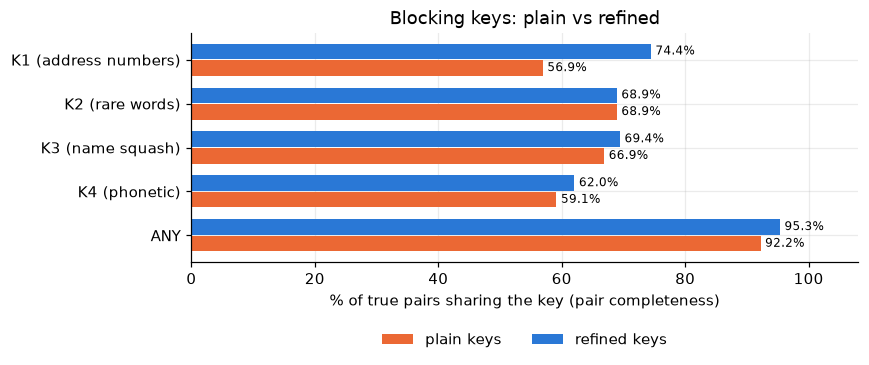

In [14]:
INITIALS = re.compile(r'(?<=\b\w) (?=\w\b)')   # 'l l c' -> 'llc', 'p c' -> 'pc'
trail_counts = Counter()
for df in (samples['train_s1'], samples['test_s1']):          # unsupervised: names only, no labels
    for country, grp in df.groupby('country'):
        c = Counter(INITIALS.sub('', canon(n)).split()[-1] for n in grp.business_name if canon(n))
        trail_counts.update({t for t, v in c.items() if v / len(grp) >= 0.003 and len(t) <= 12})
LEGAL = set(trail_counts)
print(len(LEGAL), 'legal/generic trailing tokens mined, e.g.', sorted(LEGAL)[:25])

def core_tokens(name):
    return [t for t in INITIALS.sub('', canon(name)).split() if t not in LEGAL]

def keys_refined(name, addr, country):
    n = nums(addr)[:3]; r2 = rare(addr, 2); core = core_tokens(name); sq = ''.join(core)
    return {
        'K1*': {(country, x, r[:3]) for x in n for r in r2},
        'K2': {(country, tuple(sorted(r2)))} if len(r2) == 2 else set(),
        'K3*': {(country, sq[:8])} if len(sq) >= 4 else set(),
        'K4*': {(country, ' '.join(jellyfish.metaphone(w) for w in core[:2]))} if core else set(),
    }

hit2 = {k: [] for k in ('K1*', 'K2', 'K3*', 'K4*')}
for s1, n2, a2 in zip(pos.s1, pos.name2, pos.addr2):
    r = s1_s.loc[s1]
    k1, k2 = keys_refined(r.business_name, r.business_address, r.country), keys_refined(n2, a2, r.country)
    for k in hit2:
        hit2[k].append(bool(k1[k] & k2[k]))
hit2 = pd.DataFrame(hit2)
hit2['ANY (K1*-K4*)'] = hit2.any(axis=1)
recall2 = hit2.mean().mul(100).round(2)

cmp = pd.DataFrame({'plain': recall[['K1', 'K2', 'K3', 'K4', 'ANY (K1-K4)']].values,
                    'refined': recall2.values}, index=['K1 (address numbers)', 'K2 (rare words)', 'K3 (name squash)', 'K4 (phonetic)', 'ANY'])
display(cmp)

fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(cmp)); h = 0.38
for i, (col, color) in enumerate([('plain', ORANGE), ('refined', BLUE)]):
    bars = ax.barh(y + (0.5 - i) * h, cmp[col].values, h - 0.03, color=color, label=col + ' keys')
    ax.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=3)
ax.set_yticks(y, cmp.index); ax.invert_yaxis(); ax.set_xlim(0, 108)
ax.set_xlabel('% of true pairs sharing the key (pair completeness)')
ax.set_title('Blocking keys: plain vs refined')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2)
plt.tight_layout(); plt.show()

In [15]:
print('true pairs missed by ALL cheap keys (these need the fuzzy TF-IDF / ANN safety net):')
print(f"remaining misses: {(~hit2['ANY (K1*-K4*)']).mean():.2%} of true pairs")
for _, r in pos[~hit2['ANY (K1*-K4*)'].values].head(10).iterrows():
    s = s1_s.loc[r.s1]
    print(f'  {s.business_name[:30]!r:32} | {s.business_address[:45]!r:47} ~ {r.name2[:30]!r:32} | {r.addr2[:45]!r}')

true pairs missed by ALL cheap keys (these need the fuzzy TF-IDF / ANN safety net):
remaining misses: 4.65% of true pairs
  'Universal Foundation Pvt Ltd'   | 'G1, Amirtha Varshini, 131, Old No.52, Kothand' ~ 'யுனிவர்சல் ஃபவுண்டேஷன் பிரைவேட' | 'GD/1, CHENNAI, Tamil Nadu'
  'Thalassery Yogi Pvt Ltd'        | '13/160-B, Kerala, Prabhajitham, Pandakkappara' ~ 'ythalassery.com'                | '#13/160-B, KANNUR, കേരളം, THALASSERY'
  'XHY Leasing'                    | 'Dombivli (East), Thane, Shop No.2, Maharashtr' ~ 'Vantageriza'                    | 'THANE, NO D/2, महाराष्ट्र, DOMBIVLI (EAST)'
  'East School of Medicine'        | '817 Vischer Avenue, Schenectady, NY'           ~ 'East Schloo of Medicine'        | ''
  'Jai Technology Private Limited' | 'House No 3, Kundalakar Ki Goth Kampoo, Gird, ' ~ 'जय टेक्नोलॉजी प्राइवेट लिमिटेड' | 'HOUE NO 3, GIRD, GWALIOR, मध्य प्रदेश'
  'Maithan & Sons Pvt. Ltd.'       | 'Emmar Arcade, Puthanparambu, Tirurangadi, Mal' ~ '+ MAITHAN PVT. SONS LTD.'

**Takeaway.** No single key is enough (57–69% each) — address keys miss number typos and empty
addresses, name keys miss rebrands and transliterations — but the **union** of the plain keys reaches
**92.2%**, and the refined keys (every number, legal tokens stripped anywhere) raise it to **95.4%**.
The remaining ~4.6% are dominated by non-Latin-script names combined with truncated/noisy addresses
and typo'd names with empty addresses → Indic **romanisation** (so name keys work across scripts) plus
the fuzzy char-trigram TF-IDF → ANN retrieval (**K5**) as the safety net. Blocking = union of K1–K5, then a cheap pre-score keeps the top-N per entity.
Pair completeness must be measured on a held-out split *before* any modelling.

## 9. Legal suffixes and abbreviations — mined, not hardcoded

In [16]:
trail = {}
for key in ('train_s1', 'test_s1'):
    df = samples[key]
    for country, grp in df.groupby('country'):
        c = Counter(canon(n).split()[-1] for n in grp.business_name if canon(n))
        trail[f'{key}:{country}'] = [f'{t} ({v / len(grp):.1%})' for t, v in c.most_common(12)]
pd.DataFrame(trail)

,train_s1:India,train_s1:US,test_s1:France,test_s1:India,test_s1:US
0,limited (59.3%),llc (26.9%),sarl (28.0%),limited (59.0%),llc (27.0%)
1,ltd (16.3%),inc (18.1%),sas (20.4%),ltd (16.5%),inc (17.9%)
2,llp (4.4%),c (3.4%),eurl (6.7%),llp (4.4%),c (3.4%)
3,co (2.0%),corp (2.0%),sa (4.8%),co (1.9%),group (2.0%)
4,trust (0.9%),pc (2.0%),sasu (4.2%),trust (0.8%),pc (2.0%)
5,corporation (0.8%),group (2.0%),sci (3.4%),corporation (0.8%),corp (1.9%)
6,company (0.8%),pllc (1.5%),ei (1.5%),company (0.8%),pllc (1.5%)
7,corp (0.7%),center (1.4%),club (1.0%),corp (0.7%),center (1.4%)
8,group (0.7%),associates (1.3%),jean (0.7%),group (0.6%),associates (1.3%)
9,clinic (0.5%),lp (1.3%),ecole (0.6%),clinic (0.6%),lp (1.3%)


In [17]:
# Abbreviation pairs: tokens present in one address of a true pair but not the other, where one is a
# prefix / subsequence of the other (e.g. dr -> drive). Mined purely from ground-truth pairs.
def is_subseq(short, long):
    it = iter(long)
    return short[0] == long[0] and all(c in it for c in short)

abbr = Counter()
for s1, a2 in zip(pos.s1, pos.addr2):
    t1, t2 = set(alpha_tokens(s1_s.loc[s1, 'business_address'])), set(alpha_tokens(a2))
    for a in t1 - t2:
        for b in t2 - t1:
            short, long = (a, b) if len(a) < len(b) else (b, a)
            if len(short) < len(long) and is_subseq(short, long):
                abbr[(short, long)] += 1
pd.DataFrame(abbr.most_common(25), columns=['(short, long)', 'count in true pairs']).T

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
"(short, long)","(st, street)","(rd, road)","(dr, drive)","(ave, avenue)","(mh, maharashtra)","(tx, texas)","(ln, lane)","(oh, ohio)","(il, illinois)","(ct, court)",...,"(in, indiana)","(gj, gujarat)","(md, maryland)","(wa, washington)","(al, alabama)","(tg, telangana)","(ca, california)","(ky, kentucky)","(mn, minnesota)","(mo, missouri)"
count in true pairs,4059,3841,3655,3008,2179,2007,1567,1318,1112,987,...,712,660,652,639,519,497,497,473,449,438


**Takeaway.** Trailing-token frequencies expose the legal suffixes per country — including French
`sarl`/`sas`/`eurl` in test S1 — without any hand-written list, and the ground truth directly yields
the abbreviation dictionary (`dr→drive`, `rd→road`, …). Both are mined from the provided data only
(fair-play compliant). Since France has no labels, French abbreviations (`r`/`rue`, `av`/`avenue`)
are left to character-level similarity, which handles prefix abbreviations naturally.

## 10. France (test-only)

In [18]:
fr1 = samples['test_s1'][samples['test_s1'].country == 'France']
fr2 = samples['test_s2'][samples['test_s2'].country == 'France']
print('France S1 examples:'); display(fr1.head(5))
print('France S2 examples:'); display(fr2.head(5))
tok = lambda df: Counter(t for a in df.business_address for t in alpha_tokens(a))
top = pd.DataFrame({'S1 address tokens': [f'{t} ({n})' for t, n in tok(fr1).most_common(15)],
                    'S2 address tokens': [f'{t} ({n})' for t, n in tok(fr2).most_common(15)]})
top.T

France S1 examples:


,entity_id,business_name,business_address,country
2,S1-156285671,<< Team Ecole,"175 Boulevard du Président Franklin Roosevelt, Bordeaux, Nouvelle-Aquitaine",France
4,S1-921369899,ZNB Club SARL,"Nouvelle-Aquitaine, La Teste-de-Buch, 5 bis Rue Pierre Dignac",France
9,S1-913506265,Thermal & Fils SASU,"20 Rue Parmentier, Dunkerque, Hauts-de-France",France
22,S1-628750886,Grain & Fils,"Lille, 329 Avenue de Dunkerque, Hauts-de-France",France
32,S1-466641145,Elephant Centre EURL,"30 Rue Lachassaigne, Bordeaux, Nouvelle-Aquitaine",France


France S2 examples:


,entity_id,business_name,business_address,country
1,S2-566025912,Marina Ecole France Sarl,"63 R. DE DIEPPE, LILLE, Hauts-de-France",France
2,S2-158121477,SCI Ptit Àmicale,"18 RUE JEN ZAY, Dunkerque, Nord",France
7,S2-770341988,sci ligue ici parents,"NO. 5 ALLÉE DES HÊTRES, Pornic, Loire-Atlantique",France
24,S2-647447093,Tunisie Inter Cie International SARL,"77 AV LEON JOUHAUX, LILLE",France
39,S2-262646344,OZT ÀMICALE SAS,"24 R DESAIX, TOURCOING, Hauts-de-France",France


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
S1 address tokens,de (44205),rue (29358),la (19863),france (17578),hauts (17462),nouvelle (14751),aquitaine (14748),loire (12533),pays (12526),bordeaux (7510),nantes (6528),du (6097),lille (5923),des (5426),avenue (5307)
S2 address tokens,de (23511),rue (16672),la (11018),loire (7816),bordeaux (6981),nantes (6156),lille (5686),du (5526),france (5441),hauts (5359),des (5165),nord (4745),gironde (4686),nouvelle (4594),aquitaine (4590)


**Takeaway.** French records follow the same noise generator (uppercasing, `Rue`→`R.`/`R`,
`Avenue`→`AV`, region vs département, spurious accents, `SARL`/`SAS`/`SCI` legal forms which may
appear as a *prefix*). House numbers still lead the address, so the address-number keys transfer.
Accent stripping + char-level similarity + order-invariant token features are all language-agnostic.
Legal forms must be stripped from both ends of the name.

## 11. EDA conclusions → design decisions

| # | Evidence (this notebook) | Design decision |
|---|---|---|
| 1 | ~24M rows, 10¹³ possible pairs, 8 GB RAM | Parquet + int32 row indices; blocking per country; S1 processed in chunks; training on a sample of S1 entities while blocking against the **full** satellite pool |
| 2 | Zero S2/S3 ids claimed by >1 entity (§4) | **Partition constraint** in the decision layer: each satellite record goes to at most one S1 entity (highest probability wins) |
| 3 | ~¼ of satellite records are distractors (§4) | Train on **hard negatives** produced by our own blocker, not random pairs |
| 4 | Singletons are a small minority but worth 1.0 each; most entities have 2–5 matches (§3) | **Per-entity expected-F0.5** cut (choose k, including k = 0) instead of one global threshold |
| 5 | Address numbers are the strongest signal (num-Jaccard 0.70 vs 0.007) but the *lead* number is noisy; 9% of true pairs share no name (§7) | **Address-first**: K1 keys on **every** number × rare word; numeric-set features; name keys (K3, K4) second |
| 6 | Cheap keys reach 95.4% pair completeness; misses are non-Latin names + noisy addresses (§8) | **K5** char-trigram TF-IDF → SVD → ANN top-K as the safety net; cheap pre-score caps candidates per entity |
| 7 | Reordered address components are common (§5) | Order-invariant address features (token sets, IDF-weighted overlap, token-set ratio) |
| 8 | Domain names, junk prefixes, brackets, accents, `L.L.C.` (§5, §8b) | Canonical text (join single-letter runs) + **name squash** (alphanumerics only) + longest-common-prefix feature; legal tokens stripped anywhere for the *core* name |
| 9 | 9 Indic scripts (mostly Devanagari) in 11–19% of S2/S3 names (§5) | Offset-based romanisation table covering all Indic Unicode blocks |
| 10 | Legal suffixes/abbreviations vary by country (§9) | Mine suffix list (trailing-token frequency, per split) and abbreviation map (from GT pairs); no hand-written lists |
| 11 | France only in test (§2, §10) | No country branches; `country` only as an equality key; IDF computed per split so unseen French tokens get sensible weights |
| 12 | Empty satellite addresses (§5) | Explicit empty-address flags so the GBDT learns a name-only regime |
| 13 | F0.5 weights precision 2× | Calibrated probabilities (isotonic) + threshold tuned on held-out macro-F0.5; cap matches per entity |

Next step: the pipeline in `code/business_entity_resolution/src/` implements these stages
(S0 ingest → S1 normalise/dictionaries/signatures → S2 blocking → S3 features → S4 LightGBM →
S6 decision layer → S7 output).